# 5.4.2 Score Level Comparison — FSA and WHO
Comparing calculated (ground truth) vs claimed (self-reported) FSA and WHO scores.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

files = {
    "Gemini Flash Lite": "../data/gemini_flash_lite_recipes_calculated.csv",
    "Gemini Flash":      "../data/gemini_flash_recipes_calculated.csv",
    "Grok 3 Fast":       "../data/grok_fast_recipes_calculated.csv",
    "Grok 4 Fast":       "../data/grok4_fast_recipes_calculated.csv",
    "GPT-5.4 Nano":      "../data/gpt54_nano_recipes_calculated.csv",
    "GPT-5.4 Mini":      "../data/gpt54_mini_recipes_calculated.csv",
}
models = list(files.keys())
df_all = pd.concat([pd.read_csv(p).assign(model_label=m) for m, p in files.items()], ignore_index=True)
print("Total recipes:", len(df_all))

Total recipes: 5603


## 1. Summary table — WHO and FSA scores

In [2]:
rows = []
for model, path in files.items():
    df = pd.read_csv(path)
    n  = len(df)
    calc_who  = pd.to_numeric(df["calculated_who_score"],  errors="coerce")
    claim_who = pd.to_numeric(df["claimed_who_score"],     errors="coerce")
    calc_fsa  = pd.to_numeric(df["calculated_fsa_score"],  errors="coerce")
    claim_fsa = pd.to_numeric(df["claimed_fsa_score"],     errors="coerce")
    calc_cat  = df["calculated_fsa_category"].str.lower()
    claim_cat = df["claimed_fsa_category"].str.lower()
    agree     = (calc_cat == claim_cat).sum()
    over1     = ((claim_who - calc_who) > 1).sum()
    rows.append({
        "Model":             model,
        "n":                 n,
        "Calc WHO":          round(calc_who.mean(), 2),
        "Claim WHO":         round(claim_who.mean(), 2),
        "WHO diff":          round(claim_who.mean() - calc_who.mean(), 2),
        "WHO r":             round(calc_who.corr(claim_who), 2),
        "Calc FSA":          round(calc_fsa.mean(), 2),
        "Claim FSA":         round(claim_fsa.mean(), 2),
        "FSA agree (%)": round(agree/n*100, 1),
        "WHO overest >1pt (%)": round(over1/n*100, 1),
    })

summary_df = pd.DataFrame(rows).set_index("Model")
display(summary_df)

,n,Calc WHO,Claim WHO,WHO diff,WHO r,Calc FSA,Claim FSA,FSA agree (%),WHO overest >1pt (%)
Model,,,,,,,,,
Gemini Flash Lite,888,2.30,4.79,2.49,0.32,10.36,6.72,8.1,80.3
Gemini Flash,884,2.72,5.86,3.14,0.22,10.21,4.83,7.2,86.2
Grok 3 Fast,1006,2.42,5.12,2.70,0.41,10.36,5.96,5.0,86.8
Grok 4 Fast,972,2.85,4.93,2.08,0.26,10.17,6.05,6.6,68.7
GPT-5.4 Nano,877,2.33,4.69,2.36,0.31,10.68,7.73,4.2,80.7
GPT-5.4 Mini,976,2.62,4.97,2.35,0.41,10.69,7.13,3.5,77.2


## 2. FSA category distribution — calculated vs claimed (all models combined)

In [ ]:
order  = ["healthy", "moderate", "unhealthy"]
colors = ["#2ecc71", "#f39c12", "#e74c3c"]

calc_counts    = df_all["calculated_fsa_category"].str.lower().value_counts().reindex(order, fill_value=0)
claimed_counts = df_all["claimed_fsa_category"].str.lower().value_counts().reindex(order, fill_value=0)

x = np.arange(len(order))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, calc_counts.values,    width, label="Calculated (ground truth)", color="steelblue")
ax.bar(x + width/2, claimed_counts.values, width, label="Claimed (self-reported)",   color="salmon")
ax.set_xticks(x)
ax.set_xticklabels([c.capitalize() for c in order], fontsize=12)
ax.set_ylabel("Number of recipes")
ax.set_title("FSA category distribution: Calculated vs Claimed (all models)")
ax.legend()
for i, v in enumerate(calc_counts.values):
    ax.text(i - width/2, v + 30, str(v), ha="center", fontsize=9)
for i, v in enumerate(claimed_counts.values):
    ax.text(i + width/2, v + 30, str(v), ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("figures/fsa_category_shift.png", dpi=300, bbox_inches="tight")
plt.show()

## 3. FSA category distribution per model (side by side)

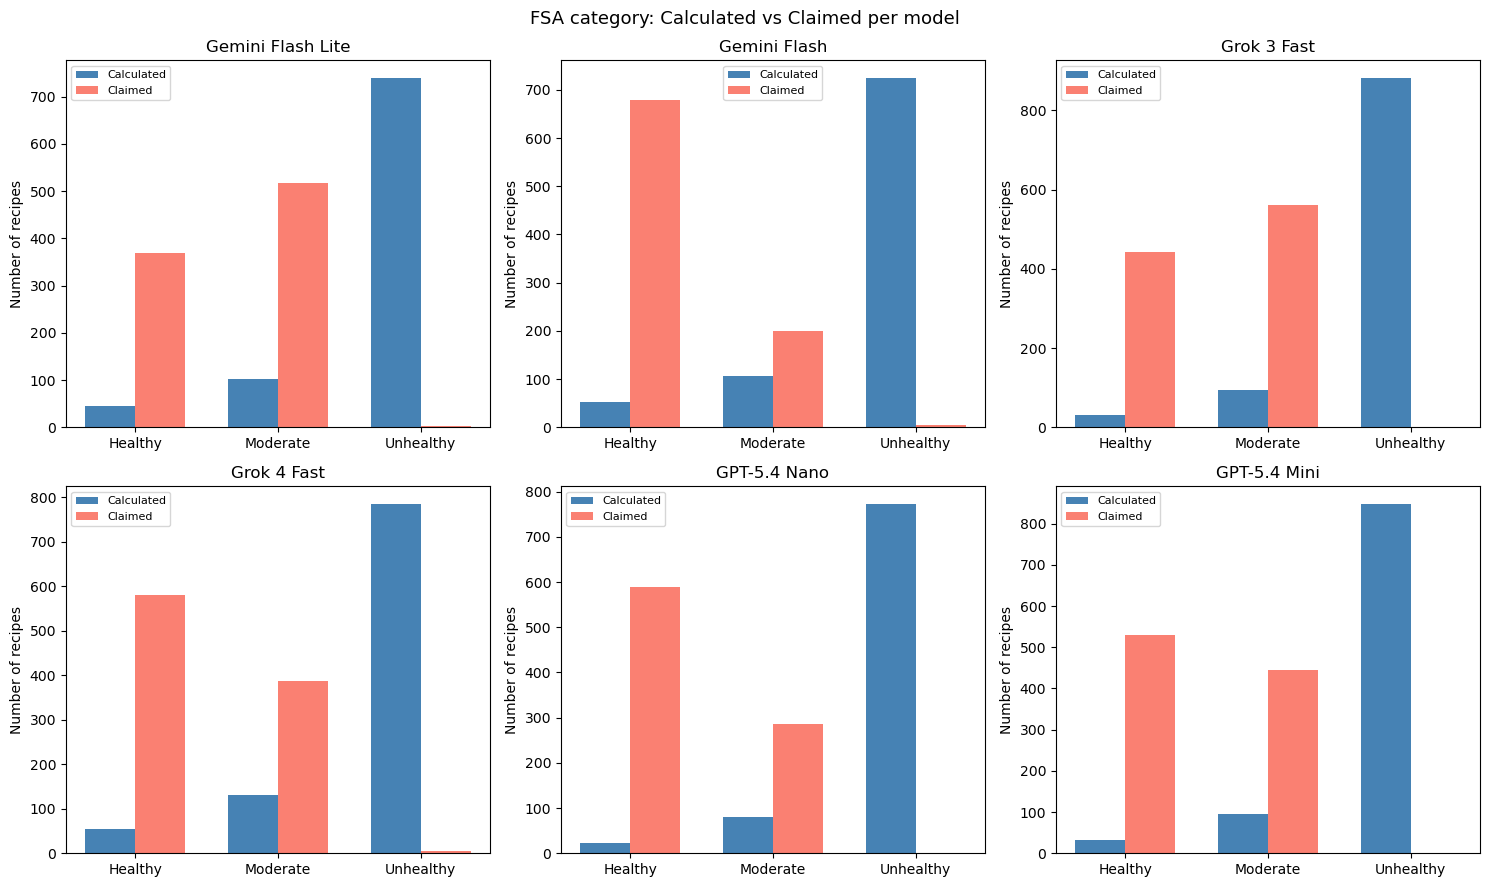

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, (model, path) in enumerate(files.items()):
    df  = pd.read_csv(path)
    ax  = axes[i]
    calc_c   = df["calculated_fsa_category"].str.lower().value_counts().reindex(order, fill_value=0)
    claimed_c= df["claimed_fsa_category"].str.lower().value_counts().reindex(order, fill_value=0)
    x = np.arange(len(order))
    ax.bar(x - width/2, calc_c.values,    width, color="steelblue", label="Calculated")
    ax.bar(x + width/2, claimed_c.values, width, color="salmon",    label="Claimed")
    ax.set_xticks(x)
    ax.set_xticklabels([c.capitalize() for c in order])
    ax.set_title(model)
    ax.set_ylabel("Number of recipes")
    ax.legend(fontsize=8)

plt.suptitle("FSA category: Calculated vs Claimed per model", fontsize=13)
plt.tight_layout()
plt.savefig("figures/fsa_category_per_model.png", dpi=300, bbox_inches="tight")
plt.show()

## 4. WHO mean score — calculated vs claimed (bar chart)

In [ ]:
calc_who_means    = [pd.to_numeric(pd.read_csv(p)["calculated_who_score"], errors="coerce").mean() for p in files.values()]
claimed_who_means = [pd.to_numeric(pd.read_csv(p)["claimed_who_score"],    errors="coerce").mean() for p in files.values()]

x = np.arange(len(models))
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, calc_who_means,    width, label="Calculated (ground truth)", color="steelblue")
bars2 = ax.bar(x + width/2, claimed_who_means, width, label="Claimed (self-reported)",   color="salmon")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20, ha="right")
ax.set_ylabel("Mean WHO score (0–7)")
ax.set_ylim(0, 7)
ax.set_title("Mean WHO score: Calculated vs Claimed by model")
ax.legend()
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f"{bar.get_height():.2f}", ha="center", fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f"{bar.get_height():.2f}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig("figures/who_mean_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. WHO scatter — calculated vs claimed per recipe (per model)

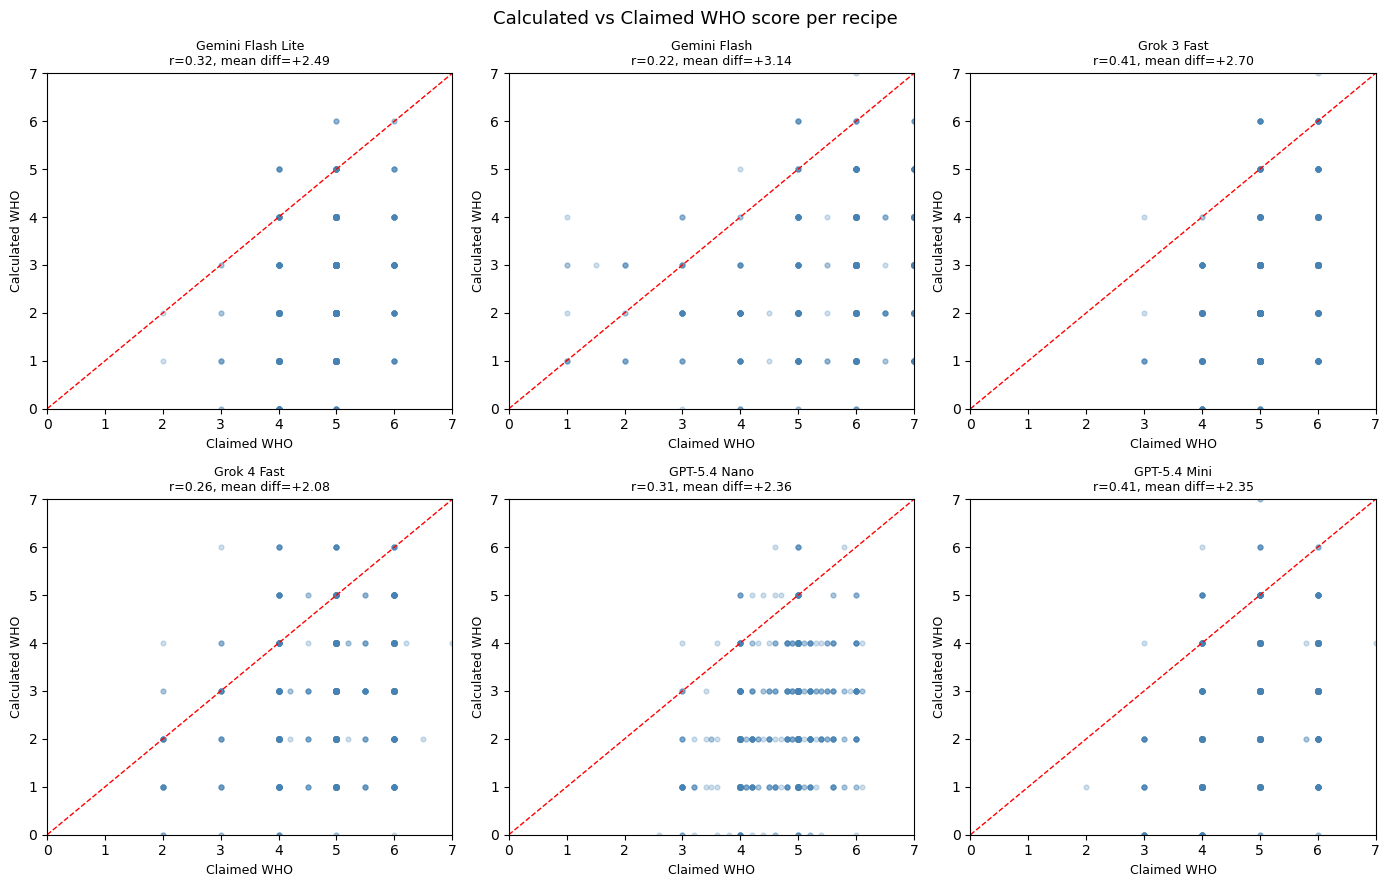

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for i, (model, path) in enumerate(files.items()):
    df   = pd.read_csv(path)
    calc = pd.to_numeric(df["calculated_who_score"],  errors="coerce")
    claim= pd.to_numeric(df["claimed_who_score"],     errors="coerce")
    mask = calc.notna() & claim.notna()
    corr = calc[mask].corr(claim[mask])
    diff = (claim[mask] - calc[mask]).mean()
    axes[i].scatter(claim[mask], calc[mask], alpha=0.25, s=12, color="steelblue")
    axes[i].plot([0,7],[0,7],"r--",lw=1, label="y=x")
    axes[i].set_xlim(0,7); axes[i].set_ylim(0,7)
    axes[i].set_xlabel("Claimed WHO", fontsize=9)
    axes[i].set_ylabel("Calculated WHO", fontsize=9)
    axes[i].set_title(f"{model}\nr={corr:.2f}, mean diff={diff:+.2f}", fontsize=9)

plt.suptitle("Calculated vs Claimed WHO score per recipe", fontsize=13)
plt.tight_layout()
plt.savefig("figures/who_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. WHO difference distribution (claimed - calculated) per model

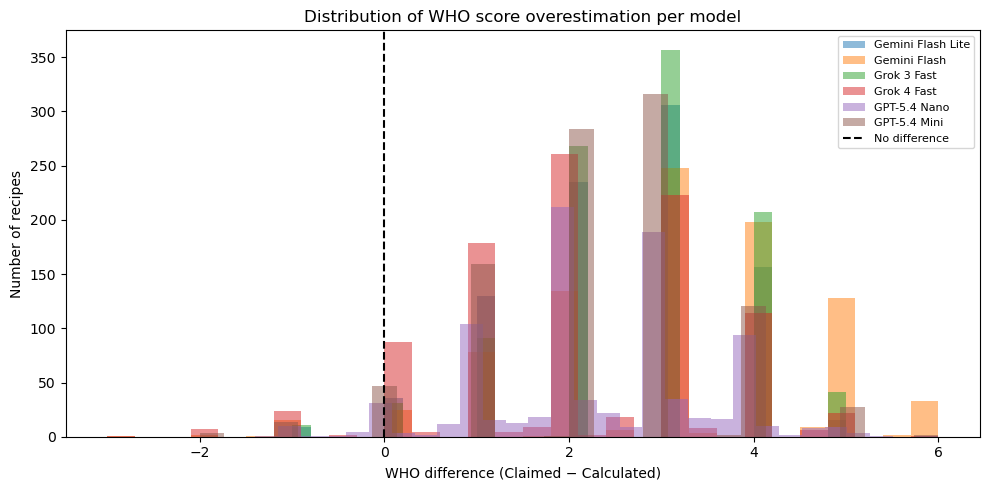

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
for model, path in files.items():
    df   = pd.read_csv(path)
    calc = pd.to_numeric(df["calculated_who_score"],  errors="coerce")
    claim= pd.to_numeric(df["claimed_who_score"],     errors="coerce")
    diff = (claim - calc).dropna()
    ax.hist(diff, bins=30, alpha=0.5, label=model)
ax.axvline(0, color="black", lw=1.5, linestyle="--", label="No difference")
ax.set_xlabel("WHO difference (Claimed − Calculated)")
ax.set_ylabel("Number of recipes")
ax.set_title("Distribution of WHO score overestimation per model")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("figures/who_diff_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Confusion matrix — FSA categories (calculated vs claimed), all models combined

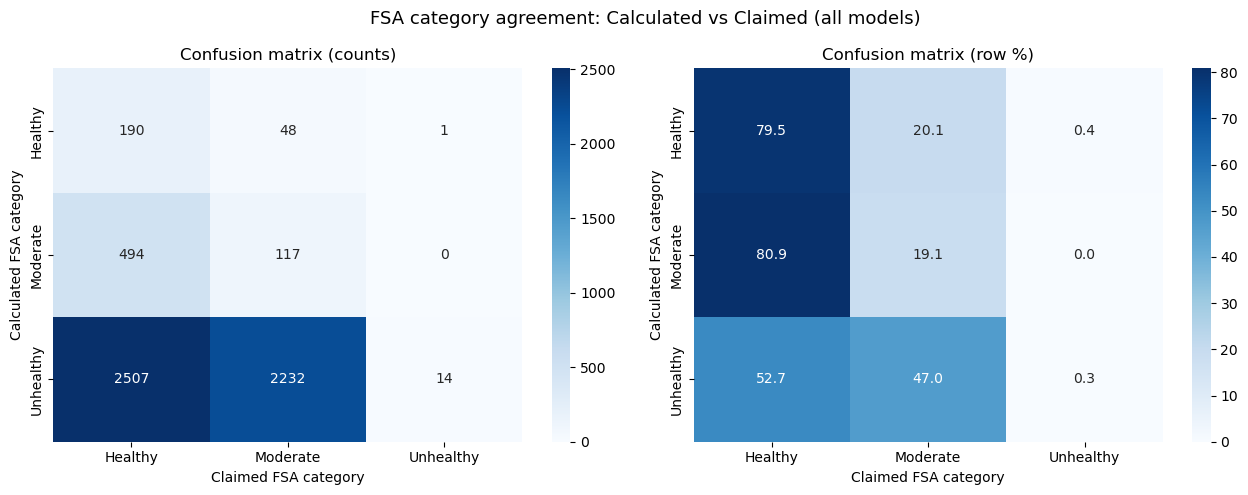


Row = Calculated (true), Column = Claimed (predicted)


In [8]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

calc_cat  = df_all["calculated_fsa_category"].str.lower()
claim_cat = df_all["claimed_fsa_category"].str.lower()
mask      = calc_cat.notna() & claim_cat.notna()

cm = confusion_matrix(calc_cat[mask], claim_cat[mask], labels=order)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm, annot=True, fmt="d", ax=axes[0],
            xticklabels=[c.capitalize() for c in order],
            yticklabels=[c.capitalize() for c in order],
            cmap="Blues")
axes[0].set_title("Confusion matrix (counts)")
axes[0].set_xlabel("Claimed FSA category")
axes[0].set_ylabel("Calculated FSA category")

sns.heatmap(cm_pct, annot=True, fmt=".1f", ax=axes[1],
            xticklabels=[c.capitalize() for c in order],
            yticklabels=[c.capitalize() for c in order],
            cmap="Blues")
axes[1].set_title("Confusion matrix (row %)")
axes[1].set_xlabel("Claimed FSA category")
axes[1].set_ylabel("Calculated FSA category")

plt.suptitle("FSA category agreement: Calculated vs Claimed (all models)", fontsize=13)
plt.tight_layout()
plt.savefig("figures/fsa_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()
print("\nRow = Calculated (true), Column = Claimed (predicted)")

## 8. LaTeX table — WHO and FSA score comparison

In [9]:
latex = r"""
\begin{table}[ht]
\centering
\caption{Comparison of calculated (ground truth) and claimed (self-reported) FSA and WHO scores per model.
WHO diff = claimed $-$ calculated mean WHO score (positive values indicate overestimation).
FSA agreement = percentage of recipes where claimed and calculated FSA category match.}
\label{tab:score_comparison}
\begin{tabular}{lrrrrrrrr}
\toprule
& \multicolumn{3}{c}{WHO Score (0--7)} & \multicolumn{2}{c}{FSA Score (4--12)} & \multicolumn{2}{c}{FSA Category} \\
\cmidrule(lr){2-4}\cmidrule(lr){5-6}\cmidrule(lr){7-8}
Model & Calc. & Claimed & Diff & Calc. & Claimed & Agreement (\%) & WHO $r$ \\
\midrule
"""

for model, path in files.items():
    df = pd.read_csv(path)
    n  = len(df)
    calc_who  = pd.to_numeric(df["calculated_who_score"],  errors="coerce")
    claim_who = pd.to_numeric(df["claimed_who_score"],     errors="coerce")
    calc_fsa  = pd.to_numeric(df["calculated_fsa_score"],  errors="coerce")
    claim_fsa = pd.to_numeric(df["claimed_fsa_score"],     errors="coerce")
    calc_cat  = df["calculated_fsa_category"].str.lower()
    claim_cat = df["claimed_fsa_category"].str.lower()
    agree_pct = (calc_cat == claim_cat).sum() / n * 100
    diff      = claim_who.mean() - calc_who.mean()
    r         = calc_who.corr(claim_who)
    latex += f"{model} & {calc_who.mean():.2f} & {claim_who.mean():.2f} & {diff:+.2f} & {calc_fsa.mean():.2f} & {claim_fsa.mean():.2f} & {agree_pct:.1f} & {r:.2f} \\\\\n"

latex += r"""
\bottomrule
\end{tabular}
\end{table}
"""
print(latex)


\begin{table}[ht]
\centering
\caption{Comparison of calculated (ground truth) and claimed (self-reported) FSA and WHO scores per model.
WHO diff = claimed $-$ calculated mean WHO score (positive values indicate overestimation).
FSA agreement = percentage of recipes where claimed and calculated FSA category match.}
\label{tab:score_comparison}
\begin{tabular}{lrrrrrrrr}
\toprule
& \multicolumn{3}{c}{WHO Score (0--7)} & \multicolumn{2}{c}{FSA Score (4--12)} & \multicolumn{2}{c}{FSA Category} \\
\cmidrule(lr){2-4}\cmidrule(lr){5-6}\cmidrule(lr){7-8}
Model & Calc. & Claimed & Diff & Calc. & Claimed & Agreement (\%) & WHO $r$ \\
\midrule
Gemini Flash Lite & 2.30 & 4.79 & +2.49 & 10.36 & 6.72 & 8.1 & 0.32 \\
Gemini Flash & 2.72 & 5.86 & +3.14 & 10.21 & 4.83 & 7.2 & 0.22 \\
Grok 3 Fast & 2.42 & 5.12 & +2.70 & 10.36 & 5.96 & 5.0 & 0.41 \\
Grok 4 Fast & 2.85 & 4.93 & +2.08 & 10.17 & 6.05 & 6.6 & 0.26 \\
GPT-5.4 Nano & 2.33 & 4.69 & +2.36 & 10.68 & 7.73 & 4.2 & 0.31 \\
GPT-5.4 Mini & 2.62 & 4.9

## 9. FSA/WHO Decomposition Analysis
Three levels of scores:
- **Claimed**: the model's self-reported FSA/WHO score
- **Recomputed**: FSA/WHO recalculated from the model's claimed nutrients (same formula as pipeline)
- **Calculated**: FSA/WHO calculated from pipeline-calculated nutrients

This decomposes the error into: (1) scoring error (claimed vs recomputed) and (2) nutrient error (recomputed vs calculated).

## 10. Calculated FSA/WHO per model and per recipe category

In [ ]:
if 'all_df' not in dir():
    all_df = pd.concat([pd.read_csv(p) for p in files.values()], ignore_index=True)
    models = sorted(all_df['model'].unique())

rows = []
for m in models:
    sub = all_df[all_df['model'] == m]
    rows.append({
        'Model': m,
        'N': len(sub),
        'Mean FSA': sub['calculated_fsa_score'].mean(),
        'Mean WHO': sub['calculated_who_score'].mean(),
        '% Healthy': (sub['calculated_fsa_category'] == 'healthy').mean() * 100,
        '% Moderate': (sub['calculated_fsa_category'] == 'moderate').mean() * 100,
        '% Unhealthy': (sub['calculated_fsa_category'] == 'unhealthy').mean() * 100,
    })
rows.append({
    'Model': 'ALL',
    'N': len(all_df),
    'Mean FSA': all_df['calculated_fsa_score'].mean(),
    'Mean WHO': all_df['calculated_who_score'].mean(),
    '% Healthy': (all_df['calculated_fsa_category'] == 'healthy').mean() * 100,
    '% Moderate': (all_df['calculated_fsa_category'] == 'moderate').mean() * 100,
    '% Unhealthy': (all_df['calculated_fsa_category'] == 'unhealthy').mean() * 100,
})
per_model = pd.DataFrame(rows).set_index('Model').round(2)
print("Calculated FSA/WHO per model:")
display(per_model)

cat_rows = []
for cat in ['breakfast', 'dinner', 'dessert']:
    sub = all_df[all_df['category'] == cat]
    cat_rows.append({
        'Category': cat,
        'N': len(sub),
        'Mean FSA': sub['calculated_fsa_score'].mean(),
        'Mean WHO': sub['calculated_who_score'].mean(),
        '% Healthy': (sub['calculated_fsa_category'] == 'healthy').mean() * 100,
        '% Moderate': (sub['calculated_fsa_category'] == 'moderate').mean() * 100,
        '% Unhealthy': (sub['calculated_fsa_category'] == 'unhealthy').mean() * 100,
    })
per_cat = pd.DataFrame(cat_rows).set_index('Category').round(1)
print("\nCalculated FSA/WHO per recipe category:")
display(per_cat)

print("\nFSA traffic-light bands (% green / amber / red) — all models:")
fsa_nutrients = [
    ('Fat', 'calculated_fsa_fat_score'),
    ('Saturated fat', 'calculated_fsa_sat_fat_score'),
    ('Sugar', 'calculated_fsa_sugar_score'),
    ('Salt', 'calculated_fsa_salt_score'),
]
band_rows = []
for name, col in fsa_nutrients:
    g = (all_df[col] == 1).mean() * 100
    a = (all_df[col] == 2).mean() * 100
    r = (all_df[col] == 3).mean() * 100
    band_rows.append({'Nutrient': name, 'Green': f'{g:.1f}%', 'Amber': f'{a:.1f}%', 'Red': f'{r:.1f}%'})
display(pd.DataFrame(band_rows).set_index('Nutrient'))

print("\nWHO criteria pass rates (%) — all models:")
components = [
    ('Protein (10-15%)', 'calculated_who_protein'),
    ('Fat (15-30%)', 'calculated_who_fat'),
    ('Sat fat (<10%)', 'calculated_who_sat_fat'),
    ('Carbs (55-75%)', 'calculated_who_carbs'),
    ('Sugar (<10%)', 'calculated_who_sugar'),
    ('Salt (≤0.2g/srv)', 'calculated_who_salt'),
    ('Fibre (≥3g/100kcal)', 'calculated_who_fibre'),
]
who_rows = []
for name, col in components:
    rate = all_df[col].mean() * 100
    who_rows.append({'Criterion': name, 'Pass rate': f'{rate:.1f}%'})
display(pd.DataFrame(who_rows).set_index('Criterion'))

## 11. FSA vs WHO scatter — colored by recipe category

In [ ]:
from scipy import stats

# Colorblind-friendly palette (Wong 2011).
cat_colors = {
    'breakfast': '#0072B2',
    'dinner':    '#E69F00',
    'dessert':   '#CC79A7',
}

fig, ax = plt.subplots(figsize=(8, 6))

for cat in ['breakfast', 'dinner', 'dessert']:
    sub = all_df[all_df['category'] == cat]
    ax.scatter(sub['calculated_fsa_score'], sub['calculated_who_score'],
               alpha=0.3, s=15, color=cat_colors[cat], label=cat.capitalize(),
               edgecolors='none', rasterized=True)

r_val, p_val = stats.pearsonr(all_df['calculated_fsa_score'], all_df['calculated_who_score'])
ax.text(0.03, 0.95, f"r = {r_val:.3f} (p < 0.001)",
        transform=ax.transAxes, fontsize=11, va='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))

ax.set_xlabel('Calculated FSA score (4–12, lower = healthier)', fontsize=11)
ax.set_ylabel('Calculated WHO score (0–7, higher = healthier)', fontsize=11)
ax.set_xlim(3.5, 12.5)
ax.set_ylim(-0.3, 7.3)
ax.set_xticks(range(4, 13))
ax.set_yticks(range(0, 8))
ax.legend(title='Category', fontsize=10, title_fontsize=10, loc='upper right')
ax.set_title('Calculated FSA vs WHO score per recipe', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('figures/fsa_vs_who_scatter.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: fsa_vs_who_scatter.png")
print(f"Pearson r = {r_val:.3f}, p = {p_val:.2e}, N = {len(all_df)}")

## 12. FSA category distribution by recipe category — stacked bar

In [ ]:
categories = ['All', 'Breakfast', 'Dinner', 'Dessert']
colors = {'Healthy': '#2ECC71', 'Moderate': '#F39C12', 'Unhealthy': '#E74C3C'}

pcts = []
for cat in categories:
    sub = all_df if cat == 'All' else all_df[all_df['category'] == cat.lower()]
    n = len(sub)
    h = (sub['calculated_fsa_category'] == 'healthy').sum() / n * 100
    m = (sub['calculated_fsa_category'] == 'moderate').sum() / n * 100
    u = (sub['calculated_fsa_category'] == 'unhealthy').sum() / n * 100
    pcts.append({'Category': cat, 'Healthy': h, 'Moderate': m, 'Unhealthy': u, 'N': n})

pct_df = pd.DataFrame(pcts).set_index('Category')

fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor('white')

y_pos = range(len(categories))
left = np.zeros(len(categories))

for label in ['Healthy', 'Moderate', 'Unhealthy']:
    vals = pct_df[label].values
    bars = ax.barh(y_pos, vals, left=left, color=colors[label],
                   edgecolor='white', linewidth=0.5, label=label, height=0.6)
    for i, (bar, val) in enumerate(zip(bars, vals)):
        if val > 4:  # skip labels on slivers
            ax.text(left[i] + val / 2, i, f'{val:.1f}%',
                    ha='center', va='center', fontsize=10, fontweight='bold',
                    color='white' if label == 'Unhealthy' else 'black')
    left += vals

ax.set_yticks(y_pos)
ax.set_yticklabels([f"{cat} (N={pct_df.loc[cat, 'N']:.0f})" for cat in categories], fontsize=11)
ax.set_xlabel('Percentage of recipes (%)', fontsize=11)
ax.set_xlim(0, 100)
ax.set_title('Calculated FSA category distribution by recipe category', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax.grid(axis='x', alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('figures/fsa_by_recipe_category_stacked.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: fsa_by_recipe_category_stacked.png")

In [ ]:
all_df = pd.concat([pd.read_csv(p) for p in files.values()], ignore_index=True)
models = sorted(all_df['model'].unique())

def fsa_cat(score):
    if score <= 6: return 'healthy'
    elif score <= 9: return 'moderate'
    else: return 'unhealthy'

all_df['claimed_fsa_cat_from_score'] = all_df['claimed_fsa_score'].apply(fsa_cat)

print("FSA SCORE DECOMPOSITION")

fsa_rows = []
for m in models:
    sub = all_df[all_df['model'] == m]
    cl = sub['claimed_fsa_score'].mean()
    rc = sub['claimed_calc_fsa_score'].mean()
    ca = sub['calculated_fsa_score'].mean()
    fsa_rows.append({'Model': m, 'N': len(sub), 'Claimed': cl, 'Recomputed': rc,
                     'Calculated': ca, 'Cl−Rec': cl - rc, 'Rec−Cal': rc - ca})

cl = all_df['claimed_fsa_score'].mean()
rc = all_df['claimed_calc_fsa_score'].mean()
ca = all_df['calculated_fsa_score'].mean()
fsa_rows.append({'Model': 'ALL MODELS', 'N': len(all_df), 'Claimed': cl,
                 'Recomputed': rc, 'Calculated': ca, 'Cl−Rec': cl - rc, 'Rec−Cal': rc - ca})

fsa_means = pd.DataFrame(fsa_rows).set_index('Model').round(2)
print("\nMean FSA scores:")
display(fsa_means)

agree_rows = []
for m in models + ['ALL MODELS']:
    sub = all_df if m == 'ALL MODELS' else all_df[all_df['model'] == m]
    ag_cl_rc = (sub['claimed_fsa_cat_from_score'] == sub['claimed_calc_fsa_category']).mean() * 100
    ag_rc_ca = (sub['claimed_calc_fsa_category'] == sub['calculated_fsa_category']).mean() * 100
    agree_rows.append({'Model': m, 'Claimed vs Recomputed (%)': round(ag_cl_rc, 1),
                       'Recomputed vs Calculated (%)': round(ag_rc_ca, 1)})

fsa_agree = pd.DataFrame(agree_rows).set_index('Model')
print("\nFSA category agreement:")
display(fsa_agree)

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cats = ['healthy', 'moderate', 'unhealthy']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm1 = confusion_matrix(all_df['claimed_fsa_cat_from_score'],
                       all_df['claimed_calc_fsa_category'],
                       labels=cats)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=cats, yticklabels=cats)
axes[0].set_xlabel('Recomputed category')
axes[0].set_ylabel('Claimed category')
axes[0].set_title('FSA: Claimed vs Recomputed (all models)')

cm2 = confusion_matrix(all_df['claimed_calc_fsa_category'],
                       all_df['calculated_fsa_category'],
                       labels=cats)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=cats, yticklabels=cats)
axes[1].set_xlabel('Calculated category')
axes[1].set_ylabel('Recomputed category')
axes[1].set_title('FSA: Recomputed vs Calculated (all models)')

plt.tight_layout()
plt.savefig('figures/fsa_decomposition_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fsa_decomposition_confusion.png")

print("\nClaimed vs Recomputed (row %):")
cm1_pct = pd.DataFrame(cm1, index=cats, columns=cats)
display((cm1_pct.div(cm1_pct.sum(axis=1), axis=0) * 100).round(1))

print("\nRecomputed vs Calculated (row %):")
cm2_pct = pd.DataFrame(cm2, index=cats, columns=cats)
display((cm2_pct.div(cm2_pct.sum(axis=1), axis=0) * 100).round(1))

In [ ]:
print("WHO SCORE DECOMPOSITION")

who_rows = []
for m in models:
    sub = all_df[all_df['model'] == m]
    cl = sub['claimed_who_score'].mean()
    rc = sub['claimed_calc_who_score'].mean()
    ca = sub['calculated_who_score'].mean()
    who_rows.append({'Model': m, 'N': len(sub), 'Claimed': cl, 'Recomputed': rc,
                     'Calculated': ca, 'Cl−Rec': cl - rc, 'Rec−Cal': rc - ca})

cl = all_df['claimed_who_score'].mean()
rc = all_df['claimed_calc_who_score'].mean()
ca = all_df['calculated_who_score'].mean()
who_rows.append({'Model': 'ALL MODELS', 'N': len(all_df), 'Claimed': cl,
                 'Recomputed': rc, 'Calculated': ca, 'Cl−Rec': cl - rc, 'Rec−Cal': rc - ca})

who_means = pd.DataFrame(who_rows).set_index('Model').round(2)
print("\nMean WHO scores:")
display(who_means)

components = ['protein', 'fat', 'sat_fat', 'carbs', 'sugar', 'salt', 'fibre']

print("\nWHO component pass rates — Recomputed (from claimed nutrients):")
recomp_rows = []
for m in models:
    sub = all_df[all_df['model'] == m]
    row = {'Model': m}
    for c in components:
        row[c] = f"{sub[f'claimed_calc_who_{c}'].mean() * 100:.1f}%"
    recomp_rows.append(row)
display(pd.DataFrame(recomp_rows).set_index('Model'))

print("\nWHO component pass rates — Calculated (from pipeline nutrients):")
calc_rows = []
for m in models:
    sub = all_df[all_df['model'] == m]
    row = {'Model': m}
    for c in components:
        row[c] = f"{sub[f'calculated_who_{c}'].mean() * 100:.1f}%"
    calc_rows.append(row)
display(pd.DataFrame(calc_rows).set_index('Model'))

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(models))
w = 0.25

claimed_means = [all_df[all_df['model'] == m]['claimed_who_score'].mean() for m in models]
recomp_means  = [all_df[all_df['model'] == m]['claimed_calc_who_score'].mean() for m in models]
calc_means    = [all_df[all_df['model'] == m]['calculated_who_score'].mean() for m in models]

ax.bar(x - w, claimed_means, w, label='Claimed (self-reported)', color='#2ecc71')
ax.bar(x,     recomp_means,  w, label='Recomputed (from claimed nutrients)', color='#f39c12')
ax.bar(x + w, calc_means,    w, label='Calculated (pipeline)', color='#e74c3c')

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20, ha='right')
ax.set_ylabel('Mean WHO score')
ax.set_title('WHO Score Decomposition: Claimed → Recomputed → Calculated')
ax.legend()
ax.set_ylim(0, 7)
plt.tight_layout()
plt.savefig('figures/who_decomposition_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: who_decomposition_bar.png")

total_gap    = all_df['claimed_who_score'].mean() - all_df['calculated_who_score'].mean()
scoring_gap  = all_df['claimed_who_score'].mean() - all_df['claimed_calc_who_score'].mean()
nutrient_gap = all_df['claimed_calc_who_score'].mean() - all_df['calculated_who_score'].mean()
print(f"\nTotal WHO overestimation:  {total_gap:+.2f} points")
print(f"  From scoring error:      {scoring_gap:+.2f} ({scoring_gap/total_gap*100:.0f}%)")
print(f"  From nutrient error:     {nutrient_gap:+.2f} ({nutrient_gap/total_gap*100:.0f}%)")